# Quorum sensing: density-dependent collective gene activation

Quorum sensing (QS) lets a bacterial population coordinate gene expression
based on cell density. Each cell secretes a small-molecule autoinducer
(AHL — acyl-homoserine lactone, in the classic LuxI/LuxR system). AHL
diffuses through the extracellular space and is sensed by every cell in the
colony. Crucially, the circuit is **auto-inductive**: AHL also activates its
own synthesis. This positive feedback loop creates a *bistable* response —
cells are locked in a low-AHL "off" state at low density, but once the
colony is large enough that secretion drives extracellular AHL above a
critical threshold, the auto-induction cascade flips every cell into a
high-AHL "on" state, switching on a GFP reporter simultaneously across the
whole population.

This notebook simulates that density-dependent transition: a growing colony
starting from two cells, accumulating AHL slowly in the "off" state, then
crossing the quorum threshold and collectively activating GFP. Visualizations
include dose-response curves, time-series tracking the population from
birth to quorum, AHL field snapshots before and after the switch, and a
color-coded animation of the colony lighting up.


In [1]:
import os
import tempfile

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

from multicellular import Cell, Colony, Environment, Field, ReactionNetwork, Simulation, visualize
from multicellular.core.reactions import Reaction

plt.rcParams["figure.dpi"] = 100


## 1. The quorum-sensing reaction network

Two Hill-Langmuir reactions — one for AHL auto-induction and one for the
GFP reporter — share the same threshold:

```
rate = beta * RNAP * (1 + alpha * C * AHL^n) / (1 + C * AHL^n)
```

At zero AHL the rate equals `beta * RNAP` (basal); as AHL rises past the
half-induction point `K_half = C^(-1/n)`, the rate approaches
`alpha * beta * RNAP` (maximum), giving an `alpha`-fold induction. With
`alpha=50` the lux-box promoter spans 50-fold between its off and on states.

`RNAP` is delivered as a *constant chemical field* (not an intracellular
species) so that growth dilution cannot deplete the transcription machinery
over many cell generations. `AHL` is also a field — diffusing and shared
by every cell — while `AHL_int` (the intracellular AHL pool produced by
LuxI and exported by the secretion reaction) is a true intracellular
species.


In [2]:
# Shared parameters
ALPHA = 50           # fold-induction at saturation (hill_langmuir alpha)
K_HALF = 0.5         # extracellular AHL concentration at half-maximal induction
N_HILL = 3           # Hill coefficient
K_BASAL = 0.05       # basal promoter firing rate
K_SEC = 2.0          # first-order AHL secretion rate
K_GFP_DEG = 0.3      # GFP degradation rate
C = 1.0 / K_HALF**N_HILL   # hill_langmuir C parameter


def build_qs_network(simulation_method="ODE"):
    """LuxI/LuxR-inspired QS circuit: AHL auto-induction drives GFP reporter."""
    hl_params = {"alpha": ALPHA, "beta": K_BASAL, "C": C, "n": N_HILL}

    # AHL_int synthesis: basal + positive feedback from extracellular AHL
    ahl_synth  = Reaction({}, {"AHL_int": 1}, catalysts=["RNAP", "AHL"],
                          rate_law_type="hill_langmuir", rate_params=hl_params)
    # Secretion: depletes AHL_int, deposits into the shared AHL field
    ahl_export = Reaction({"AHL_int": 1}, {}, exports={"AHL": 1},
                          rate_law_type="mass_action", rate_params={"k": K_SEC})
    # GFP reporter: same Hill-activation by extracellular AHL
    gfp_synth  = Reaction({}, {"GFP": 1}, catalysts=["RNAP", "AHL"],
                          rate_law_type="hill_langmuir", rate_params=hl_params)
    gfp_deg    = Reaction({"GFP": 1}, {}, rate_law_type="mass_action",
                          rate_params={"k": K_GFP_DEG})

    return ReactionNetwork(
        "quorum_sensing",
        {"ahl_synth": ahl_synth, "ahl_export": ahl_export,
         "gfp_synth": gfp_synth, "gfp_deg": gfp_deg},
        simulation_method=simulation_method,
    )


def make_qs_env(shape, bounds):
    """Environment with a diffusing AHL field and a constant RNAP field."""
    return Environment(
        shape=shape, bounds=bounds,
        fields=[
            Field("AHL",  np.zeros(shape), is_chemical=True,
                  diffuses=True, diffusivity=5e-13),
            # RNAP as a constant field prevents growth dilution from silencing
            # the promoters over successive cell generations.
            Field("RNAP", np.ones(shape),  is_chemical=True),
        ],
    )


## 2. Dose-response: GFP at steady state vs extracellular AHL

Before running a full colony simulation, it is useful to see the
steady-state response of a single cell to a fixed extracellular AHL
concentration. This dose-response curve follows directly from the
Hill-Langmuir rate law and is computed analytically:

```
GFP_ss(AHL) = K_BASAL * (1 + ALPHA * C * AHL^n) / (K_GFP_DEG * (1 + C * AHL^n))
```

The 50-fold dynamic range (from basal at `AHL = 0` to maximum at
`AHL >> K_HALF`) and the steep Hill cooperativity make the activation
effectively switch-like — most of the fold change happens in a narrow AHL
window around `K_HALF`.


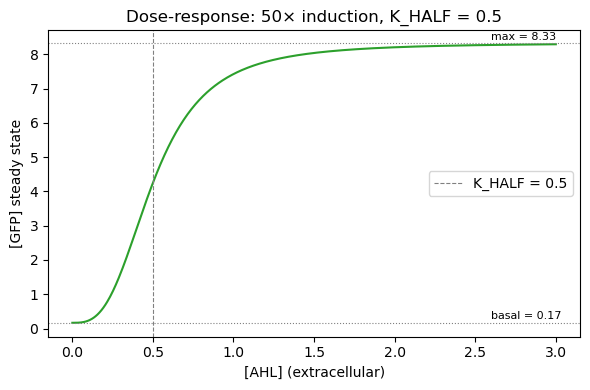

In [3]:
ahl_range = np.linspace(0.0, 3.0, 500)
gfp_ss = K_BASAL * (1 + ALPHA * C * ahl_range**N_HILL) / (K_GFP_DEG * (1 + C * ahl_range**N_HILL))
gfp_basal = K_BASAL / K_GFP_DEG
gfp_max   = K_BASAL * ALPHA / K_GFP_DEG

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ahl_range, gfp_ss, color="tab:green")
ax.axvline(K_HALF, color="gray", linestyle="--", linewidth=0.8, label=f"K_HALF = {K_HALF}")
ax.axhline(gfp_basal, color="gray", linestyle=":",  linewidth=0.8)
ax.axhline(gfp_max,   color="gray", linestyle=":",  linewidth=0.8)
ax.text(2.6, gfp_basal + 0.1, f"basal = {gfp_basal:.2f}", fontsize=8)
ax.text(2.6, gfp_max  + 0.1, f"max = {gfp_max:.2f}",   fontsize=8)
ax.set_xlabel("[AHL] (extracellular)")
ax.set_ylabel("[GFP] steady state")
ax.set_title(f"Dose-response: {ALPHA}× induction, K_HALF = {K_HALF}")
ax.legend()
fig.tight_layout()
plt.show()


## 3. Growing colony: ODE simulation and quorum transition

Two cells are seeded at low density and allowed to grow and divide. AHL
accumulates in the shared extracellular field at a rate proportional to the
number of secreting cells. While the field AHL stays well below `K_HALF`
the auto-induction is negligible, and the colony drifts in the "off" state
with near-basal GFP. As the colony reaches sufficient density, secretion
tips AHL past the threshold: the autocatalytic positive feedback kicks in,
AHL rises rapidly, and GFP lights up across every cell simultaneously — the
quorum switch fires.


In [4]:
SHAPE, BOUNDS = (15, 15), (60.0, 60.0)
GROWTH_RATE  = 0.04   # slow enough that dilution barely shifts K_half
DT, T_PRE, T_TOTAL = 0.25, 45.0, 70.0

cells_ode = [
    Cell(
        id=i, position=[29.0 + i * 2, 30.0], orientation=[1.0, 0.0], length=2.0,
        network=build_qs_network("ODE"), growth_rate=GROWTH_RATE,
        rng=np.random.default_rng(i),
    )
    for i in range(2)
]

colony_ode = Colony(cells_ode, make_qs_env(SHAPE, BOUNDS), k=10.0, drag=1.0)
sim_ode    = Simulation(colony_ode, dt=DT, t_max=T_PRE)
df_ode     = sim_ode.run(show_progress=False)

# Save pre-quorum field snapshot, then continue to T_TOTAL.
snap_pre  = colony_ode.environment.get_field("AHL").values.copy()
df_ode    = sim_ode.run(t_max=T_TOTAL, show_progress=False)
snap_post = colony_ode.environment.get_field("AHL").values.copy()

per_time = df_ode.groupby("time")[["AHL", "GFP"]].mean()
n_alive  = df_ode.groupby("time")["alive"].sum()

# Find the quorum time (steepest GFP rise).
gfp_vals  = per_time["GFP"].values
ahl_vals  = per_time["AHL"].values
times_arr = per_time.index.values
dgfp      = np.gradient(gfp_vals, times_arr)
quorum_t  = times_arr[np.argmax(dgfp)]

print(f"colony grew from 2 to {int(n_alive.iloc[-1])} cells over {T_TOTAL} time units")
print(f"quorum fires at t ≈ {quorum_t:.1f}  (n_cells ≈ {int(n_alive[times_arr[np.argmax(dgfp)]])}, "
      f"AHL ≈ {ahl_vals[np.argmax(dgfp)]:.3f})")


colony grew from 2 to 48 cells over 70.0 time units
quorum fires at t ≈ 57.0  (n_cells ≈ 32, AHL ≈ 0.387)


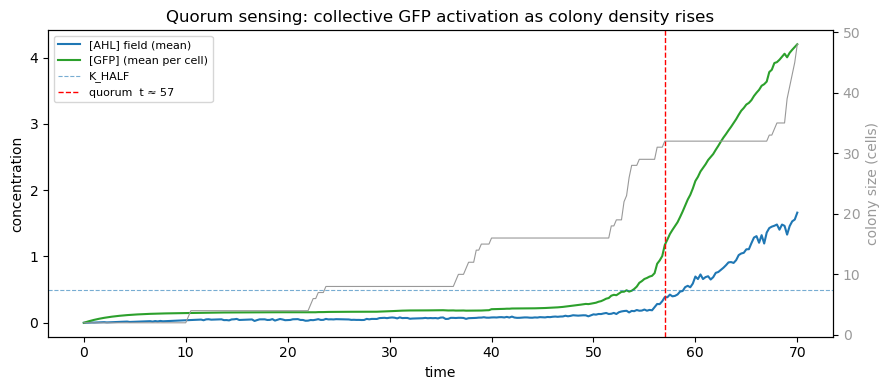

In [5]:
fig, ax1 = plt.subplots(figsize=(9, 4))

color_ahl = "tab:blue"; color_gfp = "tab:green"; color_n = "0.6"
ax1.plot(per_time.index, per_time["AHL"], color=color_ahl, label="[AHL] field (mean)")
ax1.plot(per_time.index, per_time["GFP"], color=color_gfp, label="[GFP] (mean per cell)")
ax1.axhline(K_HALF, color=color_ahl, linestyle="--", linewidth=0.8, alpha=0.6, label="K_HALF")
ax1.axvline(quorum_t, color="red", linestyle="--", linewidth=1.0, label=f"quorum  t ≈ {quorum_t:.0f}")
ax1.set_xlabel("time")
ax1.set_ylabel("concentration")

ax2 = ax1.twinx()
ax2.plot(n_alive.index, n_alive.values, color=color_n, linewidth=0.8)
ax2.set_ylabel("colony size (cells)", color=color_n)
ax2.tick_params(axis="y", labelcolor=color_n)

ax1.set_title("Quorum sensing: collective GFP activation as colony density rises")
ax1.legend(loc="upper left", fontsize=8)
fig.tight_layout()
plt.show()


## 4. AHL field: spatial maps before and after quorum

Because AHL diffuses slowly relative to the simulation timescale, it
accumulates most strongly at the colony center — where cells have been
secreting the longest — and falls off toward the edges. Before quorum the
field has barely risen above zero; after quorum the auto-induction cascade
has amplified the local AHL concentration by orders of magnitude, building
a pronounced concentration gradient centered on the colony.


/tmp/ipykernel_29048/37101391.py:18: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


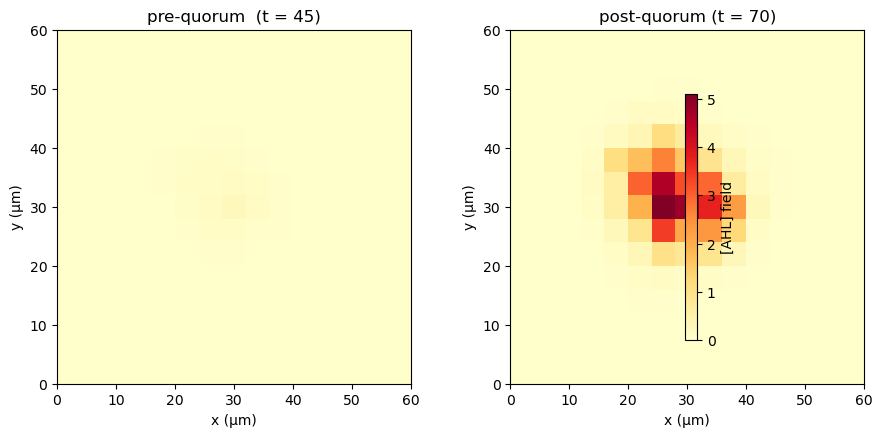

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
vmax = snap_post.max()

for ax, snap, label in [
    (axes[0], snap_pre,  f"pre-quorum  (t = {T_PRE:.0f})"),
    (axes[1], snap_post, f"post-quorum (t = {T_TOTAL:.0f})"),
]:
    im = ax.imshow(
        snap, origin="lower",
        extent=[0, BOUNDS[0], 0, BOUNDS[1]],
        vmin=0, vmax=vmax, cmap="YlOrRd",
    )
    ax.set_title(label)
    ax.set_xlabel("x (μm)")
    ax.set_ylabel("y (μm)")

fig.colorbar(im, ax=axes.tolist(), label="[AHL] field", shrink=0.8)
fig.tight_layout()
plt.show()


## 5. Stochastic response: SSA at sub- and supra-threshold AHL

At the single-cell level, stochastic gene expression means that identical
cells in the same environment do not all produce exactly the same amount of
GFP. Here a non-growing cell is exposed to a *fixed* extracellular AHL
concentration — one below `K_HALF` and one above — and the GFP trajectory
is simulated by Gillespie SSA and compared with the ODE (deterministic)
prediction. Below the threshold, stochastic bursting creates brief GFP
pulses while the mean stays low; above the threshold the cell locks into
the high state with fluctuations proportional to the square root of the
copy number.


In [7]:
def run_single_cell_at_ahl(ahl_level, method, seed, t_max=30.0):
    """Single non-growing cell sensing a *fixed* external AHL level.

    The AHL export reaction is omitted here: we want to see each cell's
    GFP response to a given steady-state AHL concentration without letting
    that cell's own secretion alter the field — isolating the sensing/
    response module from the secretion/auto-induction loop.
    """
    cell_shape = (5, 5)
    env = Environment(
        shape=cell_shape, bounds=(50.0, 50.0),
        fields=[
            Field("AHL",  np.full(cell_shape, ahl_level), is_chemical=True),
            Field("RNAP", np.ones(cell_shape),             is_chemical=True),
        ],
    )
    # Sensing-only network: GFP activation by fixed AHL, no AHL secretion.
    hl_params = {"alpha": ALPHA, "beta": K_BASAL, "C": C, "n": N_HILL}
    gfp_synth = Reaction({}, {"GFP": 1}, catalysts=["RNAP", "AHL"],
                         rate_law_type="hill_langmuir", rate_params=hl_params)
    gfp_deg   = Reaction({"GFP": 1}, {}, rate_law_type="mass_action",
                         rate_params={"k": K_GFP_DEG})
    network = ReactionNetwork(
        "gfp_sensor", {"gfp_synth": gfp_synth, "gfp_deg": gfp_deg},
        simulation_method=method,
    )
    cell = Cell(
        id=0, position=[25.0, 25.0], orientation=[1.0, 0.0], length=8.0,
        network=network, growth_rate=0.0, rng=np.random.default_rng(seed),
    )
    colony = Colony([cell], env)
    sim    = Simulation(colony, dt=0.05, t_max=t_max)
    df     = sim.run(show_progress=False)
    return df[df["cell_id"] == 0][["time", "GFP"]]


ahl_below = 0.2   # below K_HALF = 0.5
ahl_above = 1.0   # above K_HALF

df_ode_below = run_single_cell_at_ahl(ahl_below, "ODE", seed=0)
df_ode_above = run_single_cell_at_ahl(ahl_above, "ODE", seed=0)
df_ssa_below = run_single_cell_at_ahl(ahl_below, "SSA", seed=1)
df_ssa_above = run_single_cell_at_ahl(ahl_above, "SSA", seed=1)

print(f"cell volume: {Cell(id=0,position=[0,0],orientation=[1,0],length=8.0).compute_volume():.2f} um^3")
print(f"ODE GFP_ss at AHL={ahl_below}: {df_ode_below['GFP'].iloc[-1]:.3f}")
print(f"ODE GFP_ss at AHL={ahl_above}: {df_ode_above['GFP'].iloc[-1]:.3f}")


cell volume: 6.81 um^3
ODE GFP_ss at AHL=0.2: 0.658
ODE GFP_ss at AHL=1.0: 7.425


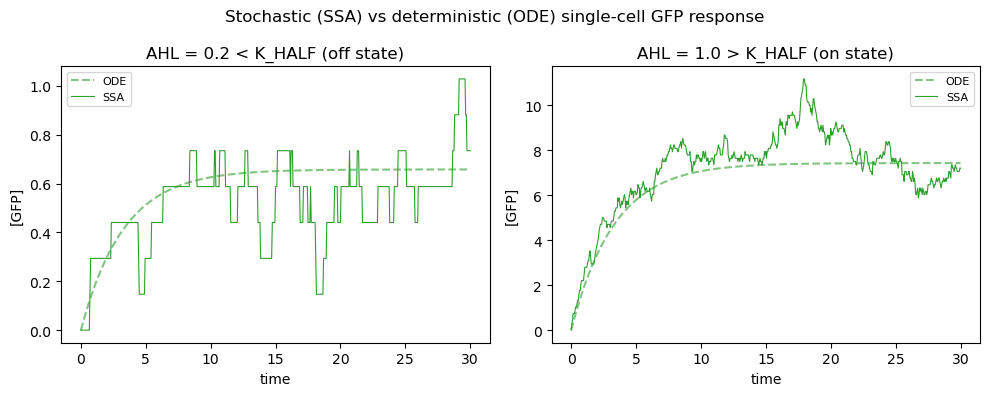

In [8]:
fig, (ax_lo, ax_hi) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

for ax, df_ode, df_ssa, ahl, title in [
    (ax_lo, df_ode_below, df_ssa_below, ahl_below, f"AHL = {ahl_below} < K_HALF (off state)"),
    (ax_hi, df_ode_above, df_ssa_above, ahl_above, f"AHL = {ahl_above} > K_HALF (on state)"),
]:
    ax.plot(df_ode["time"], df_ode["GFP"], "--", color="tab:green", alpha=0.6, label="ODE")
    ax.plot(df_ssa["time"], df_ssa["GFP"],       color="tab:green", linewidth=0.8, label="SSA")
    ax.set_xlabel("time")
    ax.set_ylabel("[GFP]")
    ax.set_title(title)
    ax.legend(fontsize=8)

fig.suptitle("Stochastic (SSA) vs deterministic (ODE) single-cell GFP response")
fig.tight_layout()
plt.show()


## 6. Colony animation: watching the quorum switch fire

`visualize(..., green="GFP")` maps each cell's GFP concentration to the
green color channel, normalized by the peak concentration over the whole
simulation. Cells appear dark before quorum and brighten to vivid green once
GFP expression kicks in. The animation is subsampled to every fourth
recorded time step so the GIF stays compact while capturing the full
trajectory from the initial two-cell seed to the post-quorum colony.


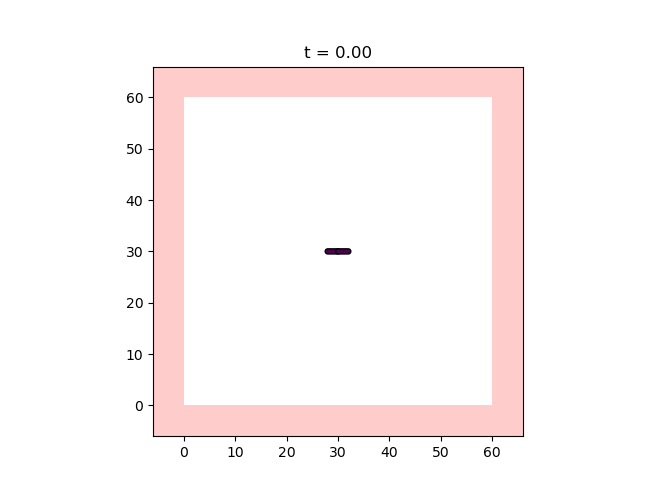

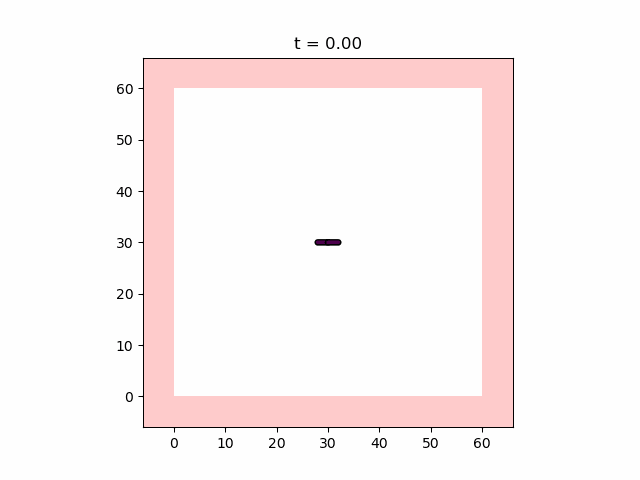

In [9]:
class _StrideView:
    """Thin wrapper that presents every `stride`-th time step to `visualize`."""
    def __init__(self, sim, stride):
        self._sim   = sim
        self._stride = stride
        self.colony = sim.colony

    def to_dataframe(self):
        df    = self._sim.to_dataframe()
        times = sorted(df["time"].unique())[:: self._stride]
        return df[df["time"].isin(times)]


output_dir = tempfile.mkdtemp()
visualize(
    _StrideView(sim_ode, stride=4), green="GFP",
    interval=100, save_path=output_dir, filename="quorum_sensing.gif", show_progress=False,
)
Image(filename=os.path.join(output_dir, "quorum_sensing.gif"))
